# Basic Example using MOGPTK

Basics of defining, fitting, and plotting results of MOGPTK model.

In [1]:
import numpy as np 
import torch
import mogptk

torch.manual_seed(1);

/home/scf/repos/mogptk-examples/.venv/lib/python3.14/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


$$k_{ij}(\tau) = \sum_{q=1}^Q \alpha^{(q)}_{ij} \exp \left( -\frac{1}{2} (\tau + \theta^{(q)}_{ij})^\top \Sigma^{(q)}_{ij}(\tau + \theta^{(q)}_{ij}) \right) \cos \left( (\tau + \theta^{(q)}_{ij})^\top \mu^{(q)}_{ij} + \phi^{(q)}_{ij} \right), \qquad \alpha^{(q)}_{ij} = w^{(q)}_{ij} (2\pi)^{n/2} | \Sigma^{(q)}_{ij} |^{1/2} $$

- No. of spectral mixture components: $Q$
- Covariance: $\Sigma_{ij}$
- Mean: $\mu_{ij}$
- Magnitude (weight of component): $w_{ij}$
- Delay: $\theta_{ij} = \theta_i - \theta_j$
- Phase: $\phi_{ij} = \phi_i - \phi_j$

## Two-band: Phase shift

Two noisy sinusoidal signals, both with same frequency ($f = 0.5$ cycles/s) and amplitude but phase shifted by $\phi = 1$ radian.

$$Y_1 \mid t \sim \mathcal{N}\left(2 \cos(2\pi \times 0.5 \times t), 0.2^2\right)$$

$$Y_2 \mid t \sim \mathcal{N}\left(2 \cos(2\pi \times 0.5 \times t + 1), 0.2^2\right)$$

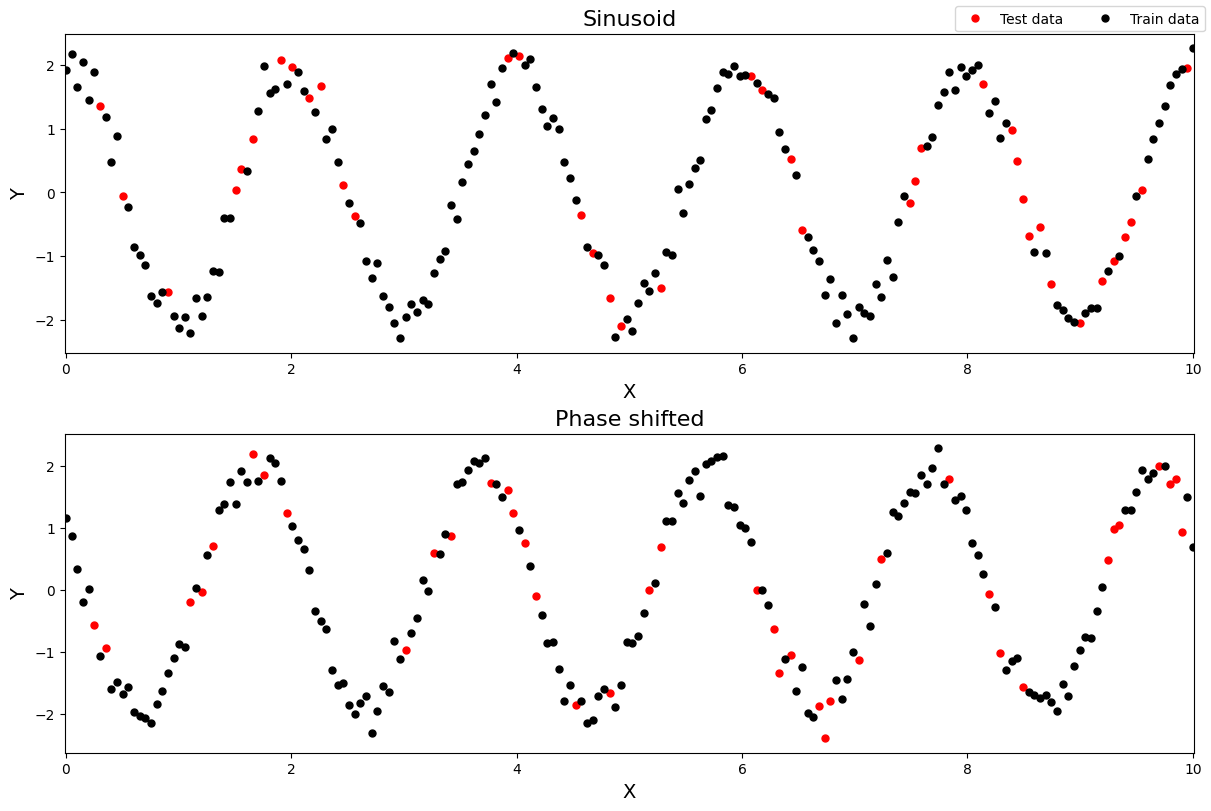

In [2]:
n_points = 200
frequency = 0.5 # cycles/s
amplitude = 2.0
phase_shift = 1 # radians

t = np.linspace(0.0, 10.0, n_points) # seconds

y1 = amplitude * np.cos(2*np.pi * frequency * t) + 0.2*np.random.normal(size=len(t))
y2 = amplitude * np.cos(2*np.pi * frequency * t + phase_shift) + 0.2*np.random.normal(size=len(t))

dataset1 = mogptk.DataSet(
    mogptk.Data(t, y1, name='Sinusoid'),
    mogptk.Data(t, y2, name='Phase shifted')
)

for data in dataset1:
    data.remove_randomly(pct=0.2)

dataset1.plot();

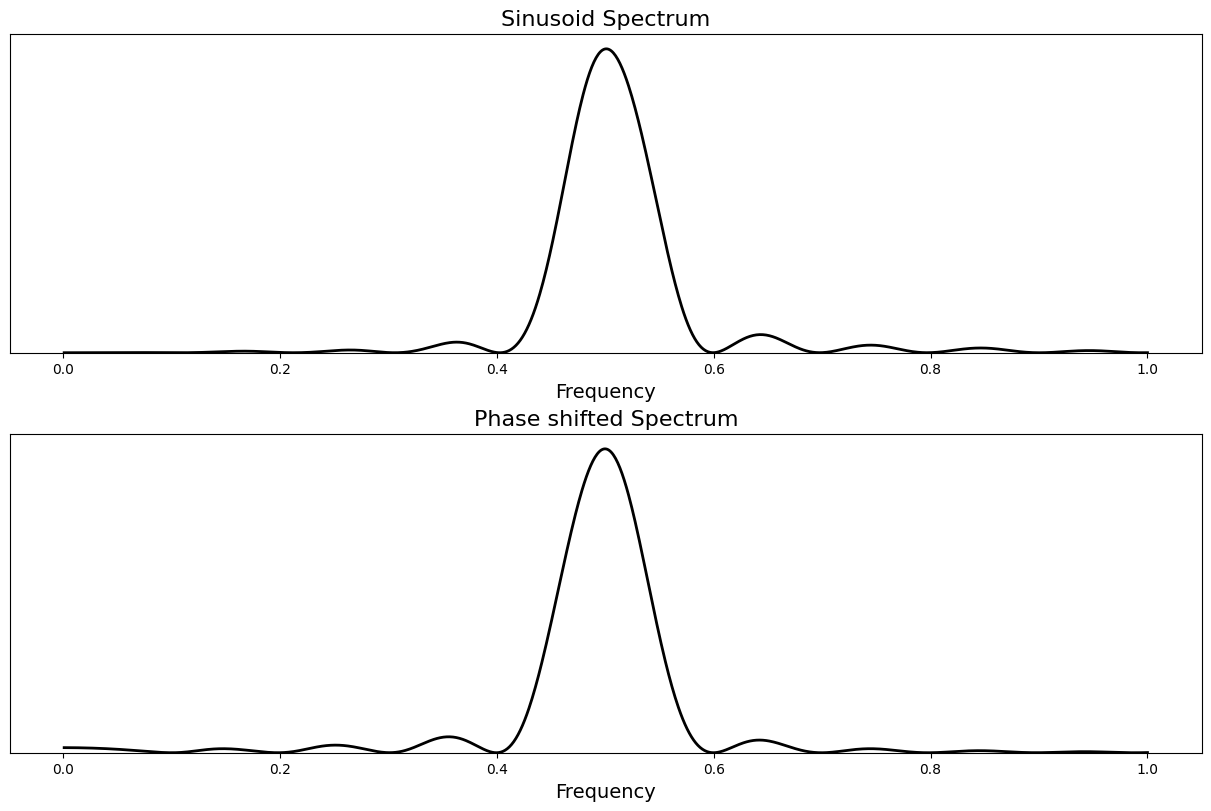

In [3]:
# LS periodogram
dataset1.plot_spectrum(maxfreq=frequency*2);

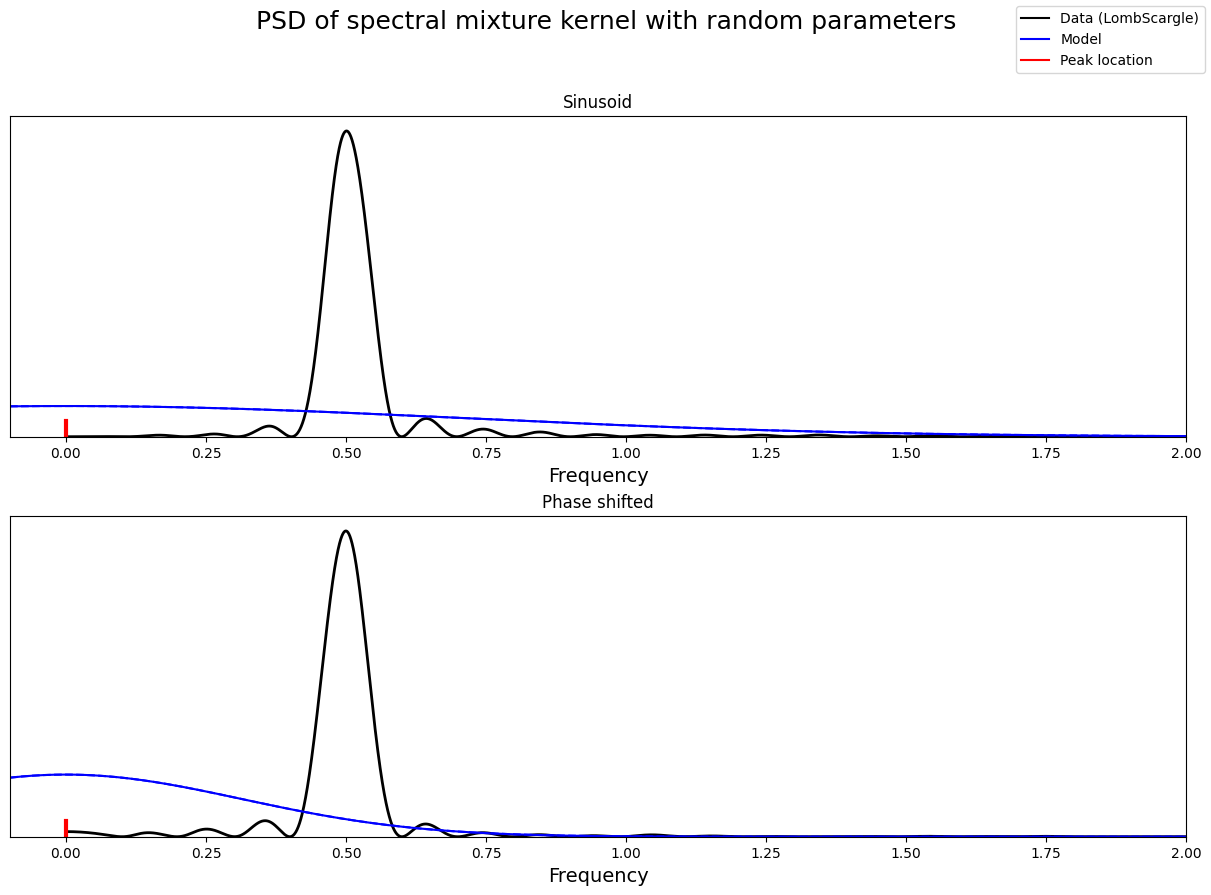

In [4]:
# create model, uncomment for different kernels 
# Q is the number of components in the mixture kernel

model1 = mogptk.MOSM(dataset1, Q=1)
model1.plot_spectrum(title='PSD of spectral mixture kernel with random parameters', maxfreq=2.0);

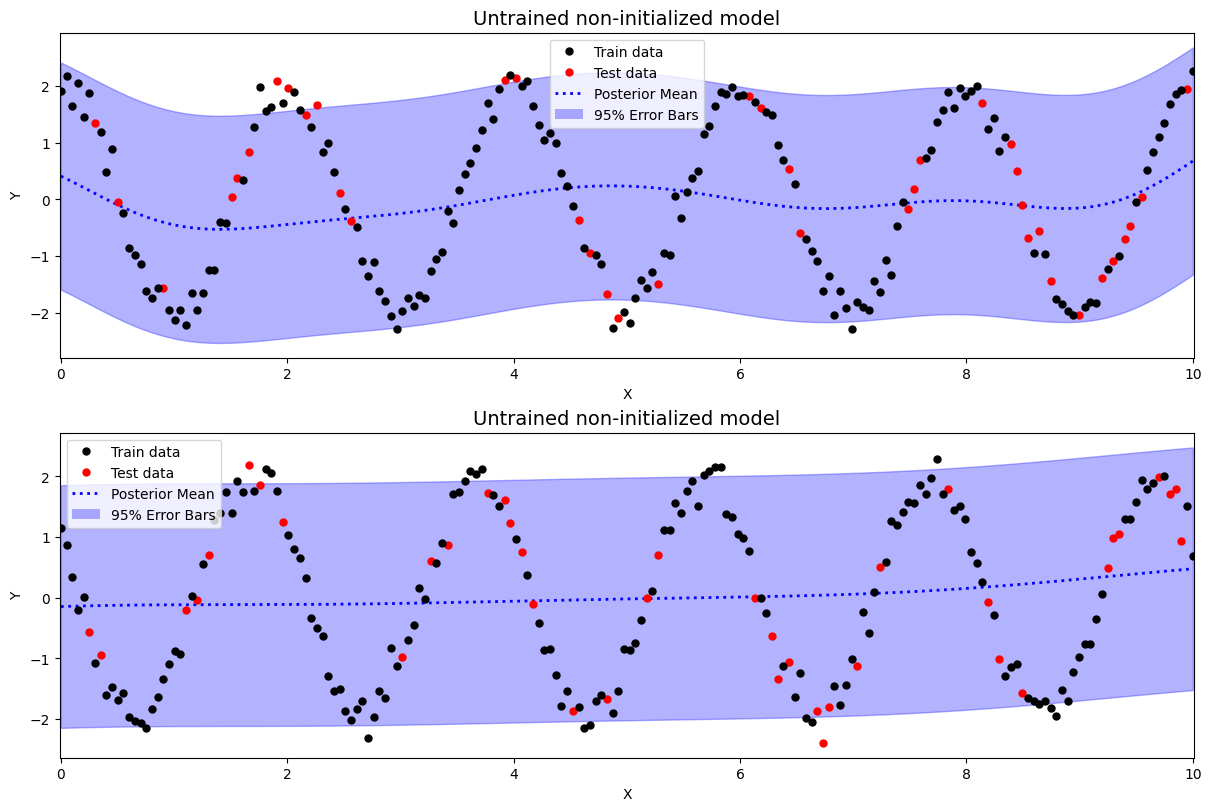

In [5]:
model1.plot_prediction(title='Untrained non-initialized model');

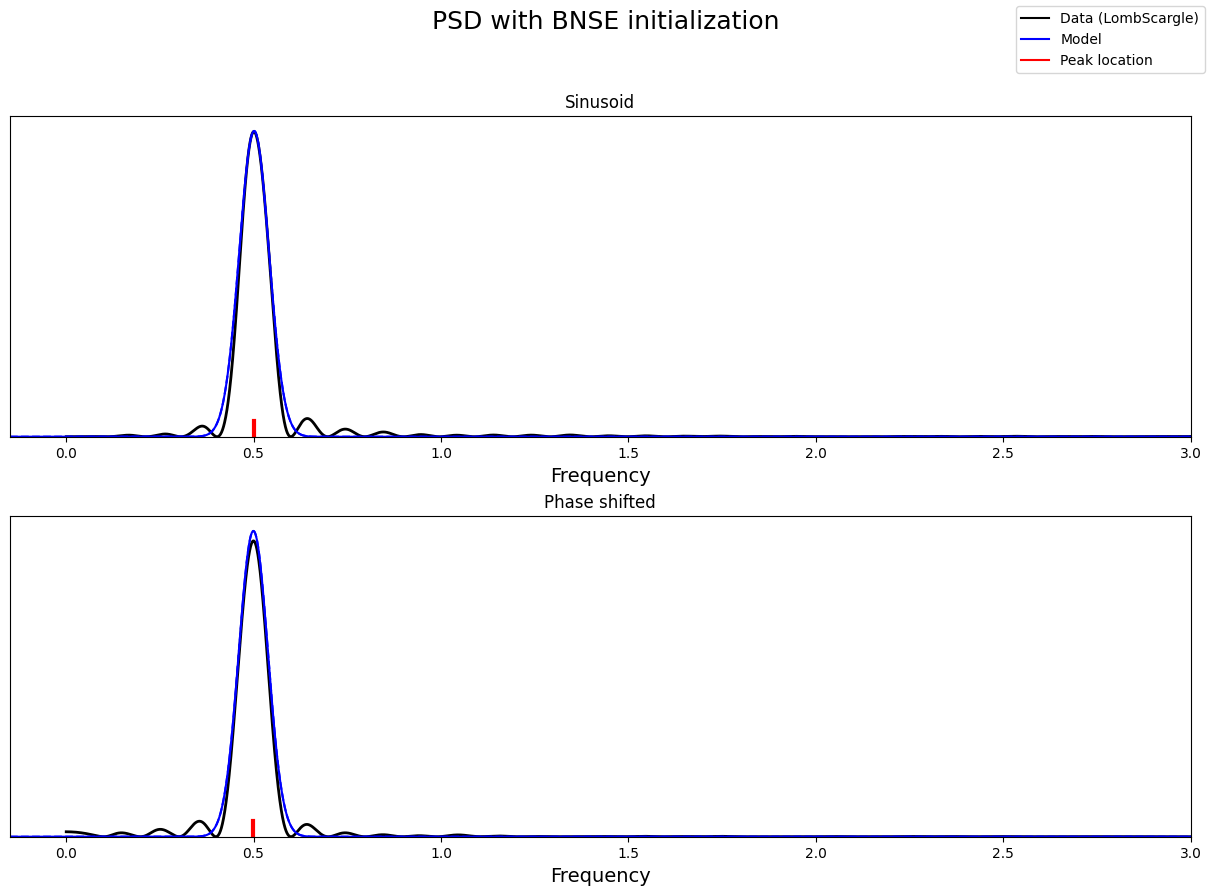

In [6]:
model1.init_parameters(method='LS', iters=500)
model1.plot_spectrum(title='PSD with BNSE initialization', maxfreq=3.0);

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[20.45703397] [20.10409859]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 9.950000000000177]",[[[0.50153015]] [[0.49953995]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00156541]] [[0.00149931]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[0.]] [[0.]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[0.] [0.]]
GaussianLikelihood.scale,"[1e-08, ∞)",[1.45977889 1.43454811]


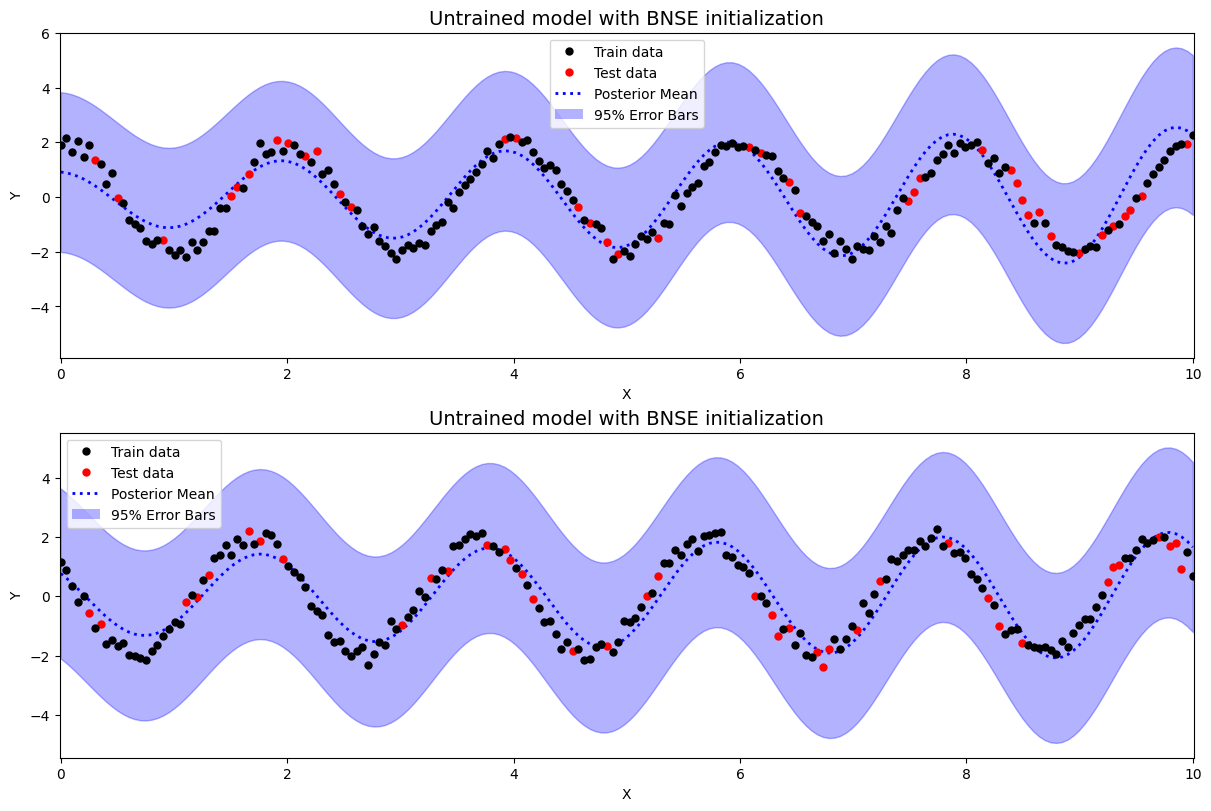

In [7]:
model1.print_parameters()
model1.plot_prediction(title='Untrained model with BNSE initialization');

Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 2
‣ Parameters: 12
‣ Training points: 320
‣ Iterations: 500


/home/scf/repos/mogptk-examples/.venv/lib/python3.14/site-packages/mogptk/model.py:384: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(self.gpr.loss())


    0/500   0:00:00  loss=     450.499  error=    0.526825
  500/500   0:00:04  loss=     142.272  error=    0.157282
Optimization finished in 4.166 seconds


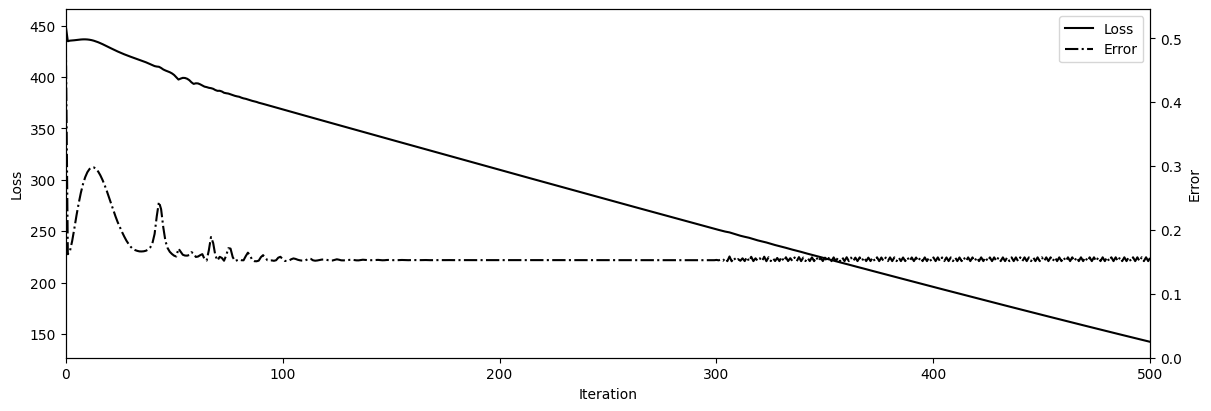

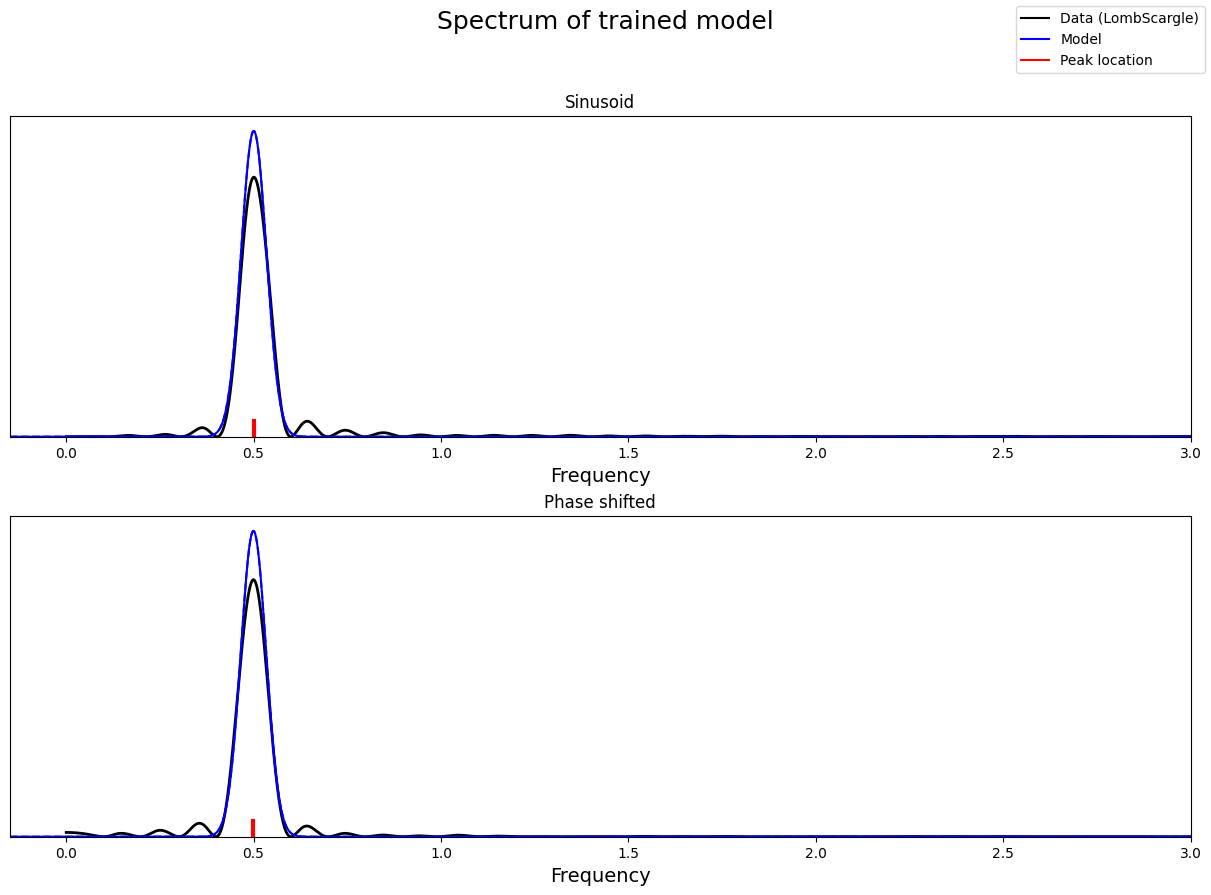

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[12.58812771] [12.48961467]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 9.950000000000177]",[[[0.50055624]] [[0.49974233]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00113275]] [[0.00113176]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[-0.05026396]] [[ 0.05026396]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[-0.05416061] [ 0.05416061]]
GaussianLikelihood.scale,"[1e-08, ∞)",[0.56567998 0.55519328]


In [8]:
model1.train(method='Adam', lr=0.02, iters=500, plot=True, error='MAE', verbose=True);
model1.plot_spectrum(title='Spectrum of trained model', maxfreq=3.0);
model1.print_parameters()

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[12.58812771] [12.48961467]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 9.950000000000177]",[[[0.50055624]] [[0.49974233]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00113275]] [[0.00113176]]]
MultiOutputSpectralMixtureKernel.delay,fixed,[[[0.]] [[0.]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[-0.05416061] [ 0.05416061]]
GaussianLikelihood.scale,"[1e-08, ∞)",[0.56567998 0.55519328]


Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 2
‣ Parameters: 10
‣ Training points: 320
‣ Iterations: 500
   500/1000   0:00:00  loss=     166.932  error=    0.270034
  1000/1000   0:00:03  loss=    -29.0439  error=    0.158892
Optimization finished in 3.932 seconds


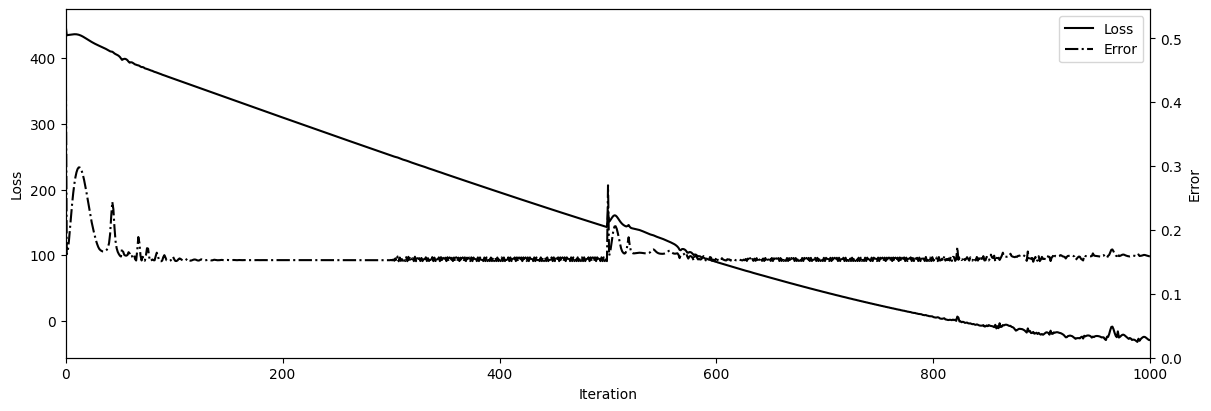

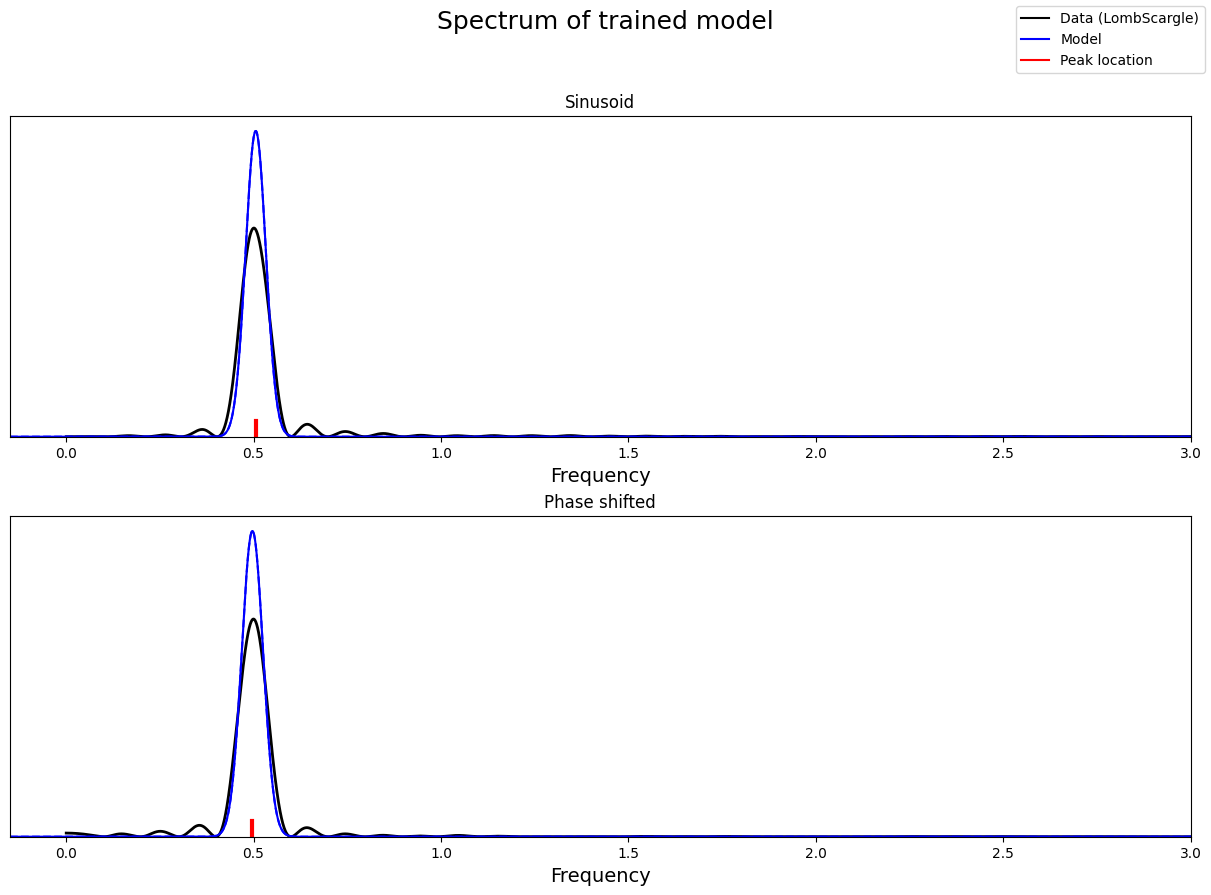

In [9]:
model1.gpr.kernel.delay.assign(np.zeros((2,1)), train=False)
model1.print_parameters()
model1.train(method='Adam', lr=0.02, iters=500, plot=True, error='MAE', verbose=True);
model1.plot_spectrum(title='Spectrum of trained model', maxfreq=3.0);

In [10]:
model1.print_parameters()

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[8.4596691 ] [8.12669237]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 9.950000000000177]",[[[0.50580141]] [[0.49699421]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.0007322 ]] [[0.00081174]]]
MultiOutputSpectralMixtureKernel.delay,fixed,[[[-0.00101845]] [[ 0.00101845]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[-0.05199999] [ 0.05199999]]
GaussianLikelihood.scale,"[1e-08, ∞)",[0.24724564 0.24117313]


## 

Recall:

$$Y_1 \mid t \sim \mathcal{N}\left(2 \cos(2\pi \times 0.5 \times t), 0.2^2\right)$$

$$Y_2 \mid t \sim \mathcal{N}\left(2 \cos(2\pi \times 0.5 \times t + 1), 0.2^2\right)$$

Cross-covariance between bands 1 and 2:

$$k_{12}(\tau) = \alpha_{12} \exp \left\{ -\frac{1}{2} \left( \tau^\top \Sigma_{12} \tau \right) \right\} \cos(\tau^\top \mu_{12} + \phi_{12})$$

$$\alpha_{12} = w_{12} (2\pi)^\frac{1}{2} |\Sigma_{12}|^\frac{1}{2}$$

$$

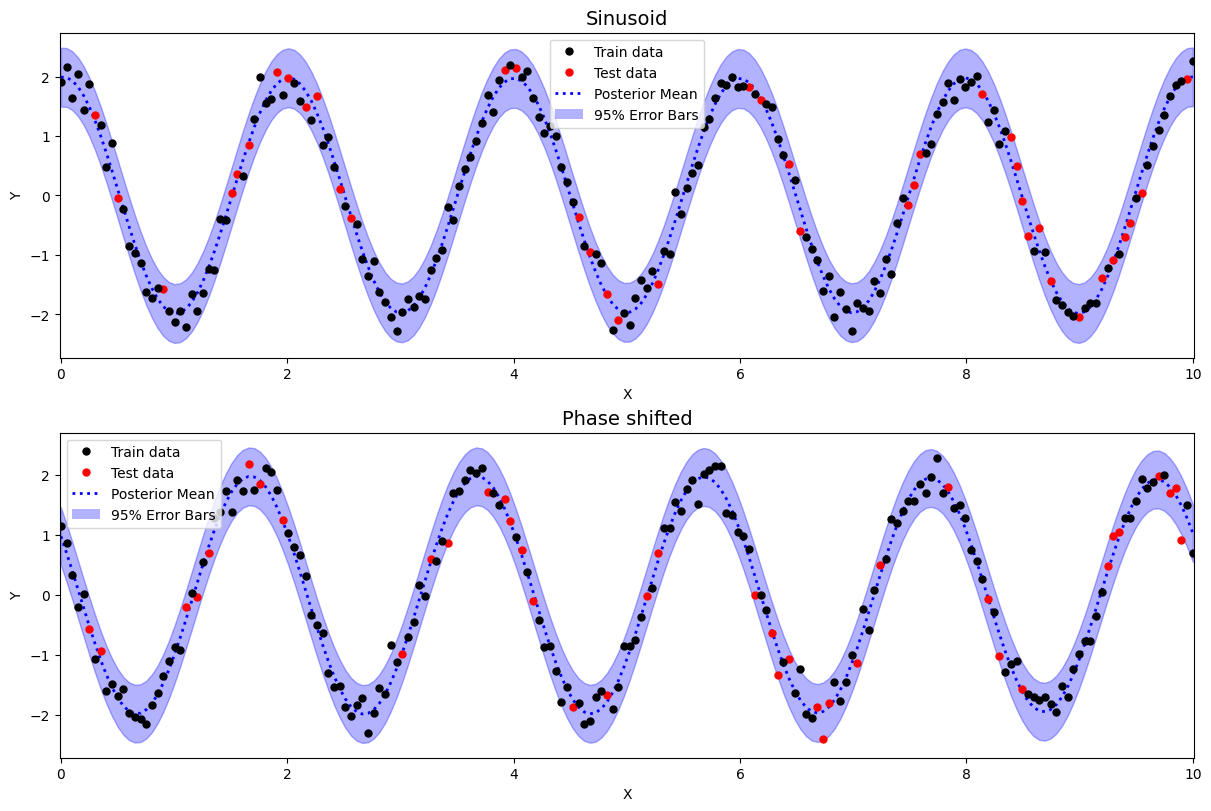

In [12]:
model1.plot_prediction();